In [1]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class import ModularStrategy
from Strategies.Modular_strategy.strategy_class_new import ModularStrategy as NewStrategy
from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes


import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [2]:
def clean_ba_dupl(df_input):
    df = df_input[['b_price', 'a_price', 'trd_price']].copy()
    df['b_price_lag'] = df['b_price'].shift(1)
    df['a_price_lag'] = df['a_price'].shift(1)
    df['mask'] = (
        (df['b_price_lag'] != df['b_price']) |
        (df['a_price_lag'] != df['a_price']) |
        (~df['trd_price'].isna())
    )
    return df['mask']

### FR-m-1

/Volumes/data/strategies_check_data/spb-fr-m-1/2025-05-15/ already exists
2025-05-15 2025-05-16
Dates out [datetime.datetime(2024, 1, 1, 0, 0), datetime.datetime(2024, 1, 11, 0, 0), datetime.datetime(2024, 1, 12, 0, 0), datetime.datetime(2024, 1, 15, 0, 0), datetime.datetime(2024, 1, 16, 0, 0), datetime.datetime(2024, 1, 17, 0, 0), datetime.datetime(2024, 1, 18, 0, 0), datetime.datetime(2024, 1, 19, 0, 0), datetime.datetime(2024, 1, 22, 0, 0), datetime.datetime(2024, 1, 23, 0, 0), datetime.datetime(2024, 3, 13, 0, 0), datetime.datetime(2024, 3, 14, 0, 0), datetime.datetime(2024, 3, 15, 0, 0), datetime.datetime(2024, 3, 18, 0, 0), datetime.datetime(2024, 3, 29, 0, 0), datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 4, 9, 0, 0), datetime.datetime(2024, 4, 10, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), datetime.datetime(2024, 5, 22, 0, 0), datetime.datetime(2024, 5, 23, 0, 0), datetime.datetime(2024, 5, 24, 0, 0), datetime.datetime(2024, 5, 27, 0, 0), datetime.datetime(2024,

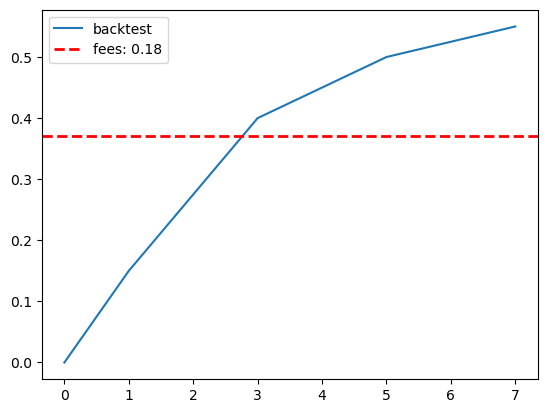

,timestamp,position,action,open_price,price_level,returns
0,2025-05-15 09:10:00.155611566,-1.0,-1.0,19.85,19.85,0.00
1,2025-05-15 09:20:17.955837219,0.0,1.0,19.85,19.70,0.15
2,2025-05-15 10:18:28.177035204,-1.0,-1.0,19.65,19.65,NaN
3,2025-05-15 10:24:45.463809125,0.0,1.0,19.65,19.40,0.25
4,2025-05-15 11:52:20.337779892,1.0,1.0,18.75,18.75,NaN
5,2025-05-15 12:01:01.139289461,0.0,-1.0,18.75,18.85,0.10
6,2025-05-15 15:28:23.836325031,1.0,1.0,20.95,20.95,NaN
7,2025-05-15 15:33:26.854268522,0.0,-1.0,20.95,21.00,0.05


In [14]:
import os
from datetime import datetime, timedelta

algo_id = 'spb-fr-m-1' 
_INSTRUMENT = 'frm1'

day = str(datetime.now().date() - timedelta(days=4))
end_day = str(datetime.now().date() -timedelta(days=3))
_STORAGE = get_curr_storage_path()
DIR_PATH  = 'strategies_check_data/' + algo_id + '/' + day + '/'
try:
    os.makedirs(_STORAGE + DIR_PATH)
except FileExistsError:
    print(_STORAGE + DIR_PATH, 'already exists')

_START_DATE = day
_END_DATE = end_day

print(_START_DATE, _END_DATE)

_ROOT = os.getcwd().split('Strategies')[0]
reg_data_file = _ROOT + 'Strategies/Sparsity_strategy/data_factory_reg.py'

!python {reg_data_file} --instrument {_INSTRUMENT} --start_date {_START_DATE} --end_date {_END_DATE} --directory_path {DIR_PATH}

_STORAGE = get_curr_storage_path()
df_data = pd.read_parquet(_STORAGE + DIR_PATH + f'backtest_obt_{_INSTRUMENT}.parquet')
# df_data = pd.read_parquet(_STORAGE + 'data_factory/' + f'backtest_obt_dey1.parquet')
df_data = df_data[~df_data['b_price'].isna()]
df_data = df_data[clean_ba_dupl(df_data)]
df_data = df_data.reset_index(names='timestamp')
df_data['ba_spread'] = (df_data['a_price'] - df_data['b_price']).round(2)
df_data.loc[df_data['trd_price'] > 0, 'trd_vol'] = 1
day = datetime(2025, 1, 24).date()
df_data = df_data[df_data['timestamp'].dt.date != day]

df_data.reset_index(inplace=True, drop=True)
df_data.reset_index(names='index', inplace=True)
df = df_data

backtest_class = BacktestModular()
# params
fixed_params = {
    'make_profit_margin': 0.25,
    'stop_loss': 0.3,
    'stop_profit': 0.1,
    'burnout_period': 5,
    'makeagg_ratio': 0.6,
    'br_fee': 0.04 / 2,
    't_end': time(17, 00),
    'hard_sl': 1.0,
    'closing_mode': 'Other',
    'close_trade_info': None
}
strategy_columns = df_data.columns.values

features_pool = {
    'feature_sparsity': FeatureSparsity,
    'feature_trd_gap': FeatureTradedAboveBO,
    'feature_ba_spread': FeatureBASpread,
    'feature_order_t1': FeatureOrderT1
}

params = {
    'feature_sparsity': {'active': True, 'params': {'thold_dense': 0.5, 'thold_sparse': 0.12}, 'suffix': ""},
    'feature_trd_gap': {'active': True, 'params': {'thold': 0.04}, 'suffix': ""},
    'feature_ba_spread': {'active': True, 'params': {'thold': 0.21}, 'suffix': ""},
    'feature_order_t1': {'active': True, 'suffix': ""}
}

data_columns = ['a_price_sparsity',
'b_price_sparsity',
'trd_gap',
'bid_t1',
'ask_t1',
'ba_spread']
indices = df[df[data_columns].notnull().all(axis=1)].index.tolist()


strategy = NewStrategy(features_pool, strategy_columns,
                        {**params, **fixed_params},
                        lead_closing=False, max_position=1)
backtest_class.simulate_strategy(strategy, df, indices, cached_returns=None)
xx = backtest_class.calc_returns_new(strategy)

import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum(), label='backtest')
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()
xx

### DE-m-1

In [16]:
import os
from datetime import datetime, timedelta

algo_id = 'spb-de-m-1' 
_INSTRUMENT = 'dem1'

day = str(datetime.now().date() - timedelta(days=3))
end_day = str(datetime.now().date())
_STORAGE = get_curr_storage_path()
DIR_PATH  = 'strategies_check_data/' + algo_id + '/' + day + '/'
try:
    os.makedirs(_STORAGE + DIR_PATH)
except FileExistsError:
    print(_STORAGE + DIR_PATH, 'already exists')

_START_DATE = day
_END_DATE = end_day

print(_START_DATE, _END_DATE)

_ROOT = os.getcwd().split('Strategies')[0]
reg_data_file = _ROOT + 'Strategies/Sparsity_strategy/data_factory_reg.py'

!python {reg_data_file} --instrument {_INSTRUMENT} --start_date {_START_DATE} --end_date {_END_DATE} --directory_path {DIR_PATH}

_STORAGE = get_curr_storage_path()
df_data = pd.read_parquet(_STORAGE + DIR_PATH + f'backtest_obt_{_INSTRUMENT}.parquet')
# df_data = pd.read_parquet(_STORAGE + 'data_factory/' + f'backtest_obt_dey1.parquet')
df_data = df_data[~df_data['b_price'].isna()]
df_data = df_data[clean_ba_dupl(df_data)]
df_data = df_data.reset_index(names='timestamp')
df_data['ba_spread'] = (df_data['a_price'] - df_data['b_price']).round(2)
df_data.loc[df_data['trd_price'] > 0, 'trd_vol'] = 1
day = datetime(2025, 1, 24).date()
df_data = df_data[df_data['timestamp'].dt.date != day]

df_data.reset_index(inplace=True, drop=True)
df_data.reset_index(names='index', inplace=True)
df = df_data

backtest_class = BacktestModular()
# params
fixed_params = {
    'make_profit_margin': 0.25,
    'stop_loss': 0.4,
    'stop_profit': 0.1,
    'burnout_period': 5,
    'makeagg_ratio': 0.6,
    'br_fee': 0.04 / 2,
    't_end': time(17, 00),
    'hard_sl': 1.0,
    'closing_mode': 'Other',
    'close_trade_info': None
}
strategy_columns = df_data.columns.values

features_pool = {
    'feature_sparsity': FeatureSparsity,
    'feature_trd_gap': FeatureTradedAboveBO,
    'feature_ba_spread': FeatureBASpread,
    'feature_order_t1': FeatureOrderT1
}

params = {
    'feature_sparsity': {'active': True, 'params': {'thold_dense': 0.5, 'thold_sparse': 0.12}, 'suffix': ""},
    'feature_trd_gap': {'active': True, 'params': {'thold': 0.04}, 'suffix': ""},
    'feature_ba_spread': {'active': True, 'params': {'thold': 0.21}, 'suffix': ""},
    'feature_order_t1': {'active': True, 'suffix': ""}
}

data_columns = ['a_price_sparsity',
'b_price_sparsity',
'trd_gap',
'bid_t1',
'ask_t1',
'ba_spread']
indices = df[df[data_columns].notnull().all(axis=1)].index.tolist()


strategy = NewStrategy(features_pool, strategy_columns,
                        {**params, **fixed_params},
                        lead_closing=False, max_position=1)
backtest_class.simulate_strategy(strategy, df, indices, cached_returns=None)
xx = backtest_class.calc_returns_new(strategy)

import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum(), label='backtest')
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()
xx

2025-05-16 2025-05-19
Dates out [datetime.datetime(2024, 1, 1, 0, 0), datetime.datetime(2024, 1, 11, 0, 0), datetime.datetime(2024, 1, 12, 0, 0), datetime.datetime(2024, 1, 15, 0, 0), datetime.datetime(2024, 1, 16, 0, 0), datetime.datetime(2024, 1, 17, 0, 0), datetime.datetime(2024, 1, 18, 0, 0), datetime.datetime(2024, 1, 19, 0, 0), datetime.datetime(2024, 1, 22, 0, 0), datetime.datetime(2024, 1, 23, 0, 0), datetime.datetime(2024, 3, 13, 0, 0), datetime.datetime(2024, 3, 14, 0, 0), datetime.datetime(2024, 3, 15, 0, 0), datetime.datetime(2024, 3, 18, 0, 0), datetime.datetime(2024, 3, 29, 0, 0), datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 4, 9, 0, 0), datetime.datetime(2024, 4, 10, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), datetime.datetime(2024, 5, 22, 0, 0), datetime.datetime(2024, 5, 23, 0, 0), datetime.datetime(2024, 5, 24, 0, 0), datetime.datetime(2024, 5, 27, 0, 0), datetime.datetime(2024, 6, 3, 0, 0), datetime.datetime(2024, 10, 25, 0, 0), datetime.datetime(202

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/data/strategies_check_data/spb-de-m-1/2025-05-16/backtest_obt_dem1.parquet'